In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import warnings
import os
import psycopg2
warnings.filterwarnings("ignore")

In [9]:
# Paramètres de connexion

DB_CONFIG = {
    "user": "postgres",
    "password": "admin",
    "host": "localhost",
    "port": "5432"
}

DB_name = "metals_db"

conn = psycopg2.connect(
    dbname="metals_db",
    user=DB_CONFIG["user"],
    password=DB_CONFIG["password"],
    host=DB_CONFIG["host"],
    port=DB_CONFIG["port"]
)

In [10]:
query = """
SELECT table_name 
FROM information_schema.tables 
WHERE table_schema = 'public'
"""

tables_df = pd.read_sql(query, conn)

print(tables_df)

           table_name
0            raw_data
1          gdelt_data
2        vix_oil_data
3        cleaned_data
4       reserves_gold
5  Macroeconomic_data
6            dim_date


In [11]:
data = {}

for table in tables_df['table_name']:
    try:
        print(f"Loading table: {table}")
        
        # IMPORTANT : ajouter les guillemets
        df = pd.read_sql(f'SELECT * FROM public."{table}"', conn)
        
        data[table] = df
        
        print(f"{table} loaded with shape {df.shape}")
        
    except Exception as e:
        print(f"Error loading {table}: {e}")


Loading table: raw_data
raw_data loaded with shape (58272, 10)
Loading table: gdelt_data
gdelt_data loaded with shape (1825411, 7)
Loading table: vix_oil_data
vix_oil_data loaded with shape (2599, 3)
Loading table: cleaned_data
cleaned_data loaded with shape (58272, 11)
Loading table: reserves_gold
reserves_gold loaded with shape (105, 4)
Loading table: Macroeconomic_data
Macroeconomic_data loaded with shape (12166, 7)
Loading table: dim_date
dim_date loaded with shape (3776, 5)


In [12]:
macro_df = data.get("Macroeconomic_data")
prices_df = data.get("cleaned_data")
geopo_df = data.get("gdelt_data")
gold_reser_df = data.get("reserves_gold")
vix_oil_df = data.get("vix_oil_data")

In [15]:

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 100)

def basic_info(df, name="DF"):
    print(f"\n{'='*50}")
    print(f"📊 DATASET: {name}")
    print(f"{'='*50}")
    
    print("\n🔹 Shape:")
    print(df.shape)
    
    print("\n🔹 Types:")
    print(df.dtypes)
    
    print("\n🔹 Missing values:")
    missing = df.isnull().sum()
    print(missing[missing > 0].sort_values(ascending=False))
    
    print("\n🔹 % Missing:")
    print((df.isnull().mean()*100).sort_values(ascending=False))
    
    print("\n🔹 Unique values:")
    print(df.nunique().sort_values())
    
    print("\n🔹 Duplicates:", df.duplicated().sum())
    
    print("\n🔹 Statistical summary:")
    display(df.describe(include="all"))


In [16]:
dfs = {
    "macro": macro_df,
    "prices": prices_df,
    "geopo": geopo_df,
    "gold_reserves": gold_reser_df,
    "vix_oil": vix_oil_df
}

for name, df in dfs.items():
    if df is not None:
        basic_info(df, name)



📊 DATASET: macro

🔹 Shape:
(12166, 7)

🔹 Types:
date            datetime64[ns]
fed_rate               float64
real_rate              float64
CPI                    float64
GDP                    float64
DXY                    float64
Unemployment           float64
dtype: object

🔹 Missing values:
GDP             11532
real_rate       11102
fed_rate        10442
Unemployment    10290
CPI             10266
DXY              1982
dtype: int64

🔹 % Missing:
GDP             94.788756
real_rate       91.254315
fed_rate        85.829361
Unemployment    84.579977
CPI             84.382706
DXY             16.291304
date             0.000000
dtype: float64

🔹 Unique values:
Unemployment      83
GDP              317
fed_rate         508
real_rate        532
CPI              861
DXY             5057
date            6083
dtype: int64

🔹 Duplicates: 6083

🔹 Statistical summary:


,date,fed_rate,real_rate,CPI,GDP,DXY,Unemployment
count,12166,1724.000000,1064.000000,1900.000000,634.000000,10184.000000,1876.000000
mean,2011-06-28 22:01:24.037481472,4.599327,2.407549,124.493271,7826.633962,106.193185,5.662260
min,1946-01-01 00:00:00,0.050000,-0.407134,21.480000,243.164000,85.469200,2.500000
25%,2009-01-21 06:00:00,1.910000,0.949360,32.850000,833.302000,93.705925,4.300000
50%,2014-10-23 00:00:00,4.280000,2.057584,109.800000,4607.669000,109.812750,5.500000
75%,2020-07-23 18:00:00,6.120000,3.565937,201.300000,13753.424000,116.655075,6.700000
max,2026-04-24 00:00:00,19.100000,7.656648,330.293000,31856.257000,130.041300,14.800000
std,NaN,3.534254,1.814312,89.784157,8258.400872,12.330142,1.704527



📊 DATASET: prices

🔹 Shape:
(58272, 11)

🔹 Types:
metals           object
Pays             object
Année             int64
date             object
gold_24k        float64
gold_22k        float64
gold_18k        float64
gold_14k        float64
gold_10k        float64
silver_price    float64
devise           object
dtype: object

🔹 Missing values:
devise    29136
dtype: int64

🔹 % Missing:
devise          50.0
Pays             0.0
metals           0.0
Année            0.0
date             0.0
gold_22k         0.0
gold_24k         0.0
gold_18k         0.0
gold_14k         0.0
gold_10k         0.0
silver_price     0.0
dtype: float64

🔹 Unique values:
metals              2
devise              6
Année              10
Pays               12
date             2428
silver_price    15702
gold_10k        18908
gold_14k        19474
gold_18k        19862
gold_24k        20060
gold_22k        20098
dtype: int64

🔹 Duplicates: 0

🔹 Statistical summary:


,metals,Pays,Année,date,gold_24k,gold_22k,gold_18k,gold_14k,gold_10k,silver_price,devise
count,58272,58272,58272.000000,58272,58272.000000,58272.000000,58272.000000,58272.000000,58272.000000,58272.000000,29136
unique,2,12,NaN,2428,NaN,NaN,NaN,NaN,NaN,NaN,6
top,gold,algerie,NaN,2017-01-02,NaN,NaN,NaN,NaN,NaN,NaN,DA
freq,29136,4856,NaN,24,NaN,NaN,NaN,NaN,NaN,NaN,4856
mean,NaN,NaN,2021.172158,NaN,3525.574984,3231.777551,2644.181830,2056.585477,1468.989541,44.267350,NaN
std,NaN,NaN,2.693450,NaN,11337.641742,10392.839198,8503.232651,6613.625479,4724.017552,148.501637,NaN
min,NaN,NaN,2017.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,2019.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,NaN,NaN,2021.000000,NaN,14.538000,13.326500,10.903500,8.480500,6.057500,0.169350,NaN
75%,NaN,NaN,2023.000000,NaN,86.112250,78.936000,64.583750,50.232000,35.880250,1.003000,NaN



📊 DATASET: geopo

🔹 Shape:
(1825411, 7)

🔹 Types:
date                   object
country                object
total_events            int64
political_events        int64
war_intensity         float64
crisis_index          float64
political_pressure    float64
dtype: object

🔹 Missing values:
Series([], dtype: int64)

🔹 % Missing:
date                  0.0
country               0.0
total_events          0.0
political_events      0.0
war_intensity         0.0
crisis_index          0.0
political_pressure    0.0
dtype: float64

🔹 Unique values:
country                  222
political_events        6373
total_events           11732
date                   17294
war_intensity          98234
political_pressure    127669
crisis_index          951574
dtype: int64

🔹 Duplicates: 0

🔹 Statistical summary:


,date,country,total_events,political_events,war_intensity,crisis_index,political_pressure
count,1825411,1825411,1.825411e+06,1.825411e+06,1.825411e+06,1.825411e+06,1.825411e+06
unique,17294,222,NaN,NaN,NaN,NaN,NaN
top,2015-05-27,USA,NaN,NaN,NaN,NaN,NaN
freq,200,17294,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2.726679e+02,6.832026e+01,5.146030e-02,1.014080e+00,2.185674e-01
std,NaN,NaN,1.487953e+03,3.867256e+02,7.754293e-02,1.669820e+00,1.446357e-01
min,NaN,NaN,1.000000e+01,0.000000e+00,0.000000e+00,-1.000000e+01,0.000000e+00
25%,NaN,NaN,2.300000e+01,4.000000e+00,0.000000e+00,1.737288e-01,1.200000e-01
50%,NaN,NaN,5.300000e+01,1.100000e+01,2.666667e-02,1.122857e+00,2.044761e-01
75%,NaN,NaN,1.580000e+02,3.500000e+01,6.840990e-02,2.021277e+00,2.943192e-01



📊 DATASET: gold_reserves

🔹 Shape:
(105, 4)

🔹 Types:
country_name    object
country_code    object
year             int64
value            int64
dtype: object

🔹 Missing values:
Series([], dtype: int64)

🔹 % Missing:
country_name    0.0
country_code    0.0
year            0.0
value           0.0
dtype: float64

🔹 Unique values:
country_name      7
country_code      7
year             15
value           105
dtype: int64

🔹 Duplicates: 0

🔹 Statistical summary:


,country_name,country_code,year,value
count,105,105,105.000000,1.050000e+02
unique,7,7,NaN,NaN
top,Tunisia,TUN,NaN,NaN
freq,15,15,NaN,NaN
mean,NaN,NaN,2017.000000,1.465920e+11
std,NaN,NaN,4.341216,1.925868e+11
min,NaN,NaN,2010.000000,2.225709e+09
25%,NaN,NaN,2013.000000,9.239745e+09
50%,NaN,NaN,2017.000000,8.392560e+10
75%,NaN,NaN,2021.000000,1.745978e+11



📊 DATASET: vix_oil

🔹 Shape:
(2599, 3)

🔹 Types:
Date    datetime64[ns]
vix            float64
oil            float64
dtype: object

🔹 Missing values:
vix    2
oil    2
dtype: int64

🔹 % Missing:
vix     0.076953
oil     0.076953
Date    0.000000
dtype: float64

🔹 Unique values:
vix     1435
oil     2106
Date    2599
dtype: int64

🔹 Duplicates: 0

🔹 Statistical summary:


,Date,vix,oil
count,2599,2597.000000,2597.000000
mean,2021-03-01 22:15:50.211619840,18.554170,64.109519
min,2016-01-04 00:00:00,9.140000,-37.630001
25%,2018-08-01 12:00:00,13.600000,51.790001
50%,2021-03-03 00:00:00,16.860001,63.580002
75%,2023-09-30 12:00:00,21.559999,74.830002
max,2026-05-01 00:00:00,82.690002,123.699997
std,NaN,7.256091,17.740527


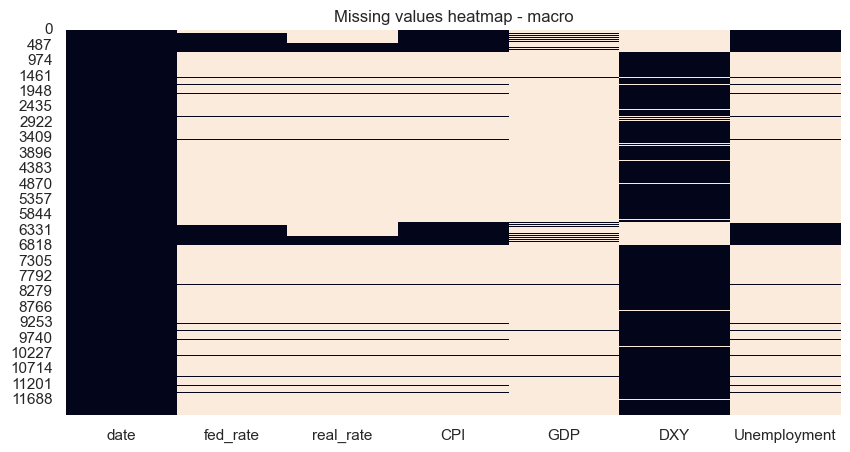

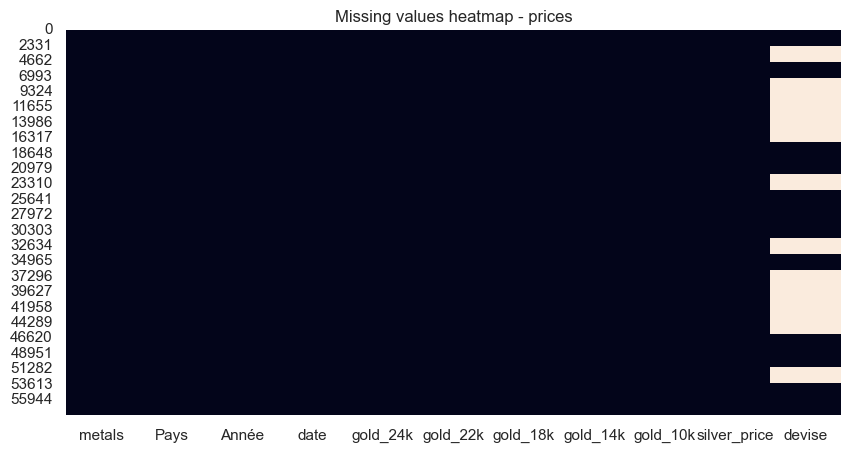

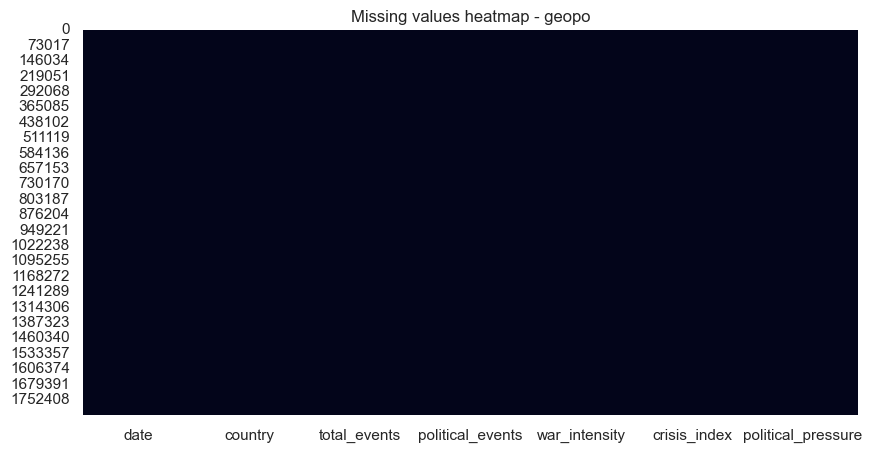

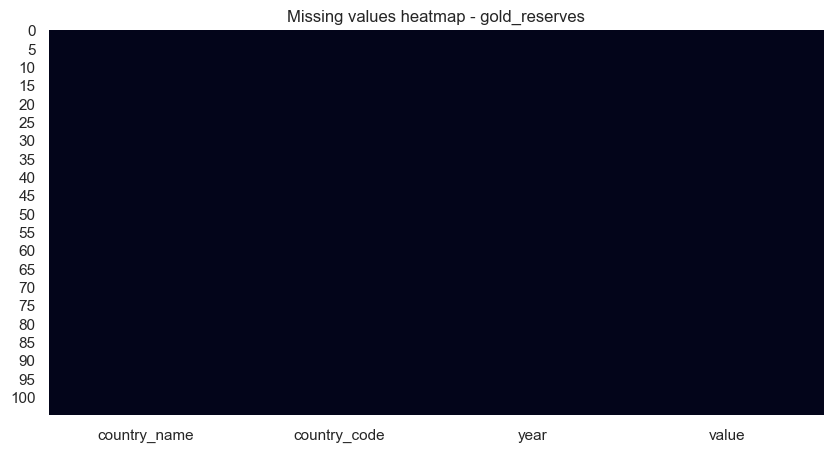

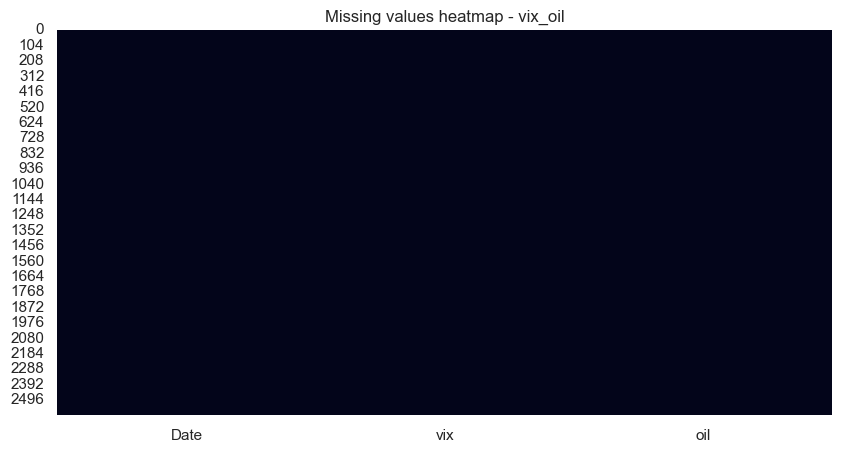

In [17]:
#valeurs manquantes
def plot_missing(df, name):
    plt.figure(figsize=(10,5))
    sns.heatmap(df.isnull(), cbar=False)
    plt.title(f"Missing values heatmap - {name}")
    plt.show()

for name, df in dfs.items():
    if df is not None:
        plot_missing(df, name)


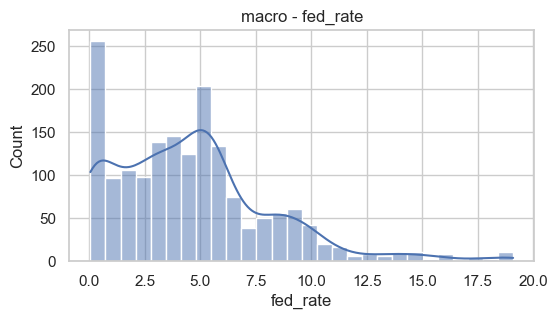

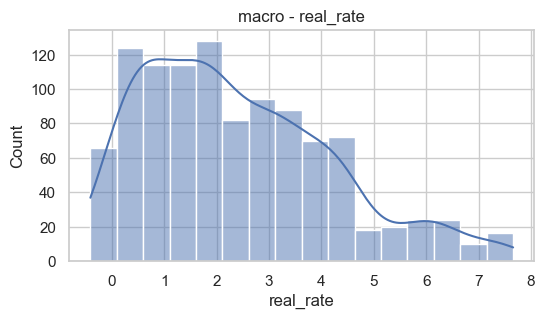

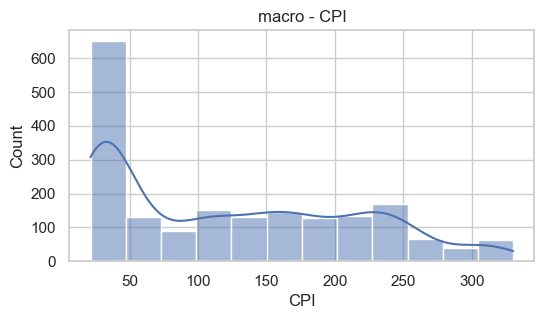

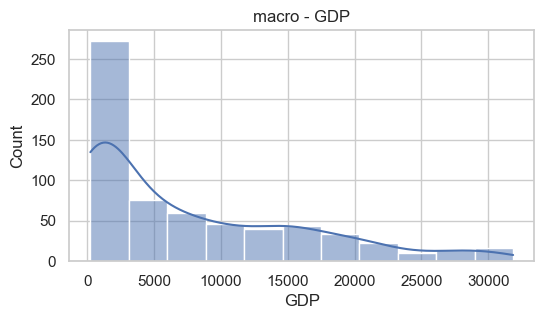

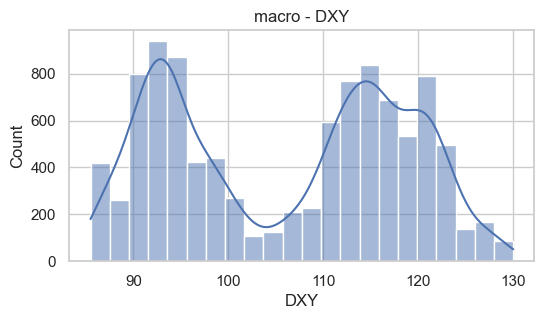

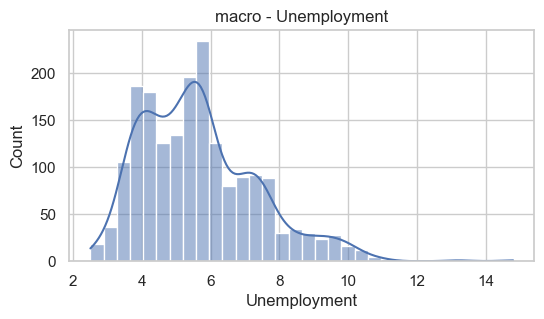

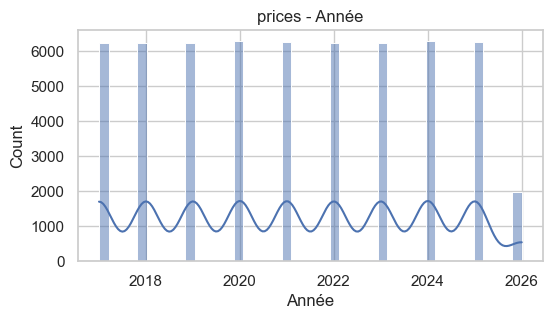

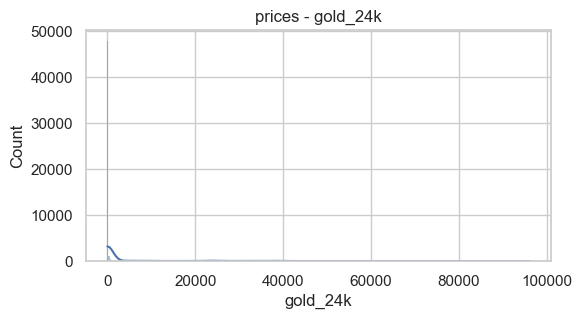

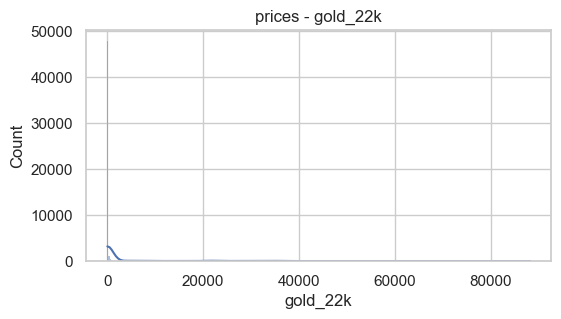

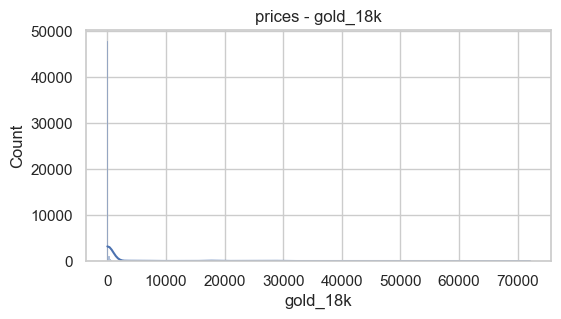

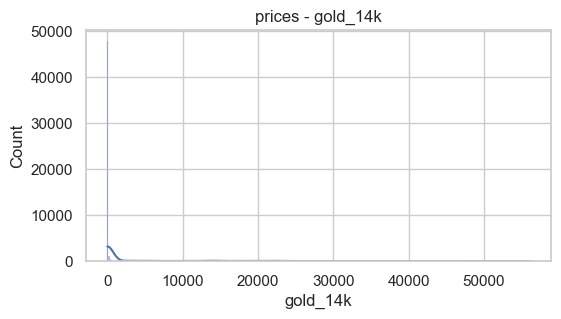

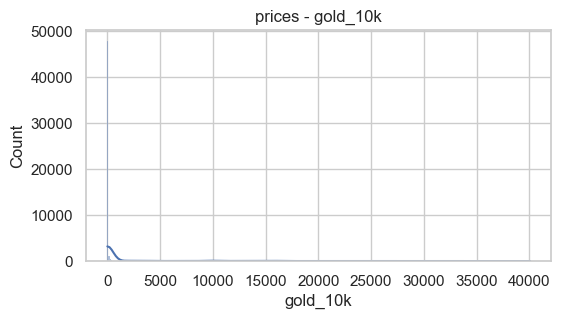

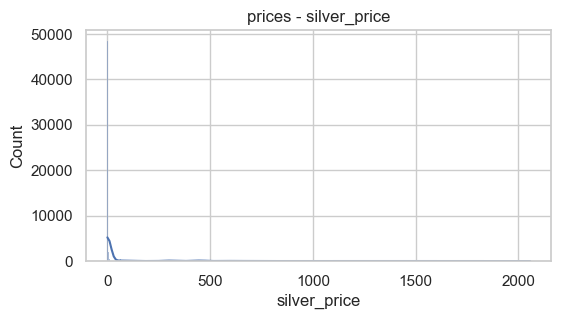

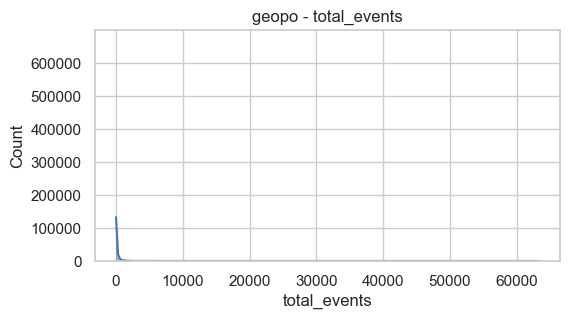

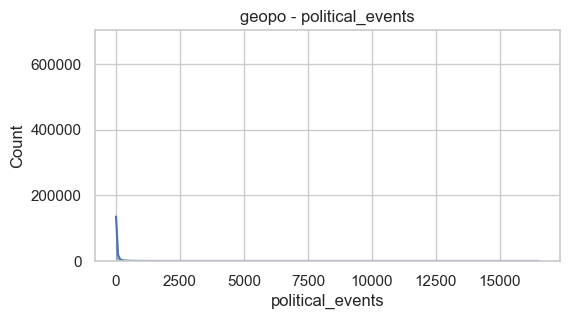

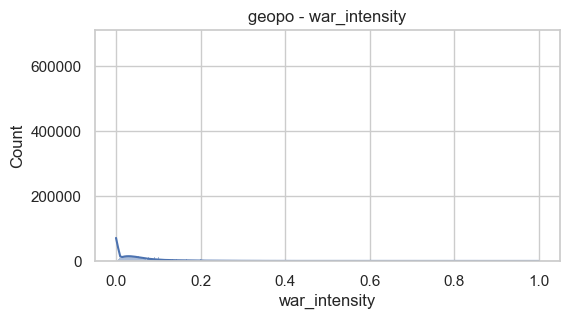

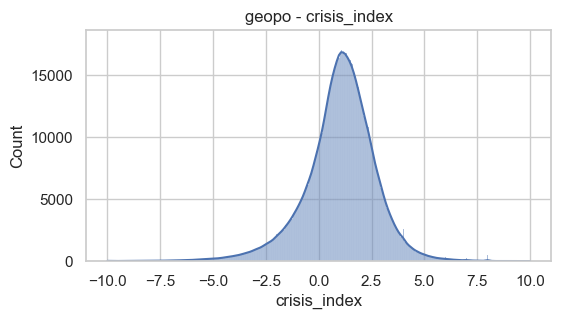

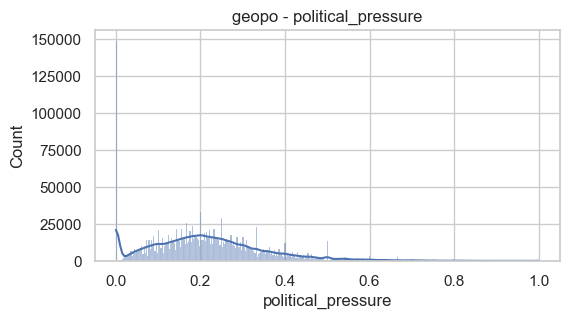

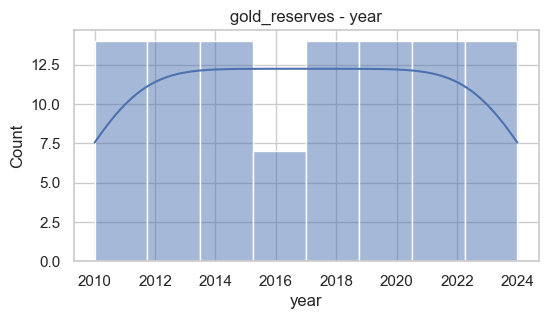

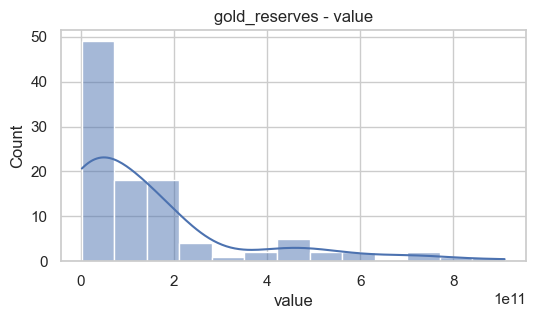

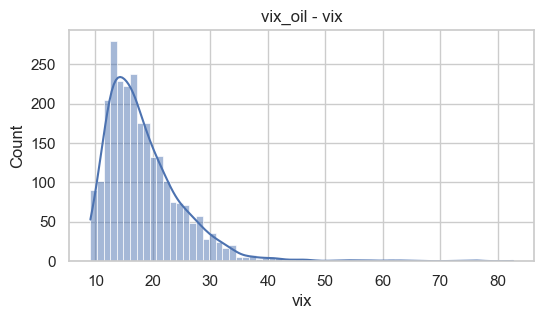

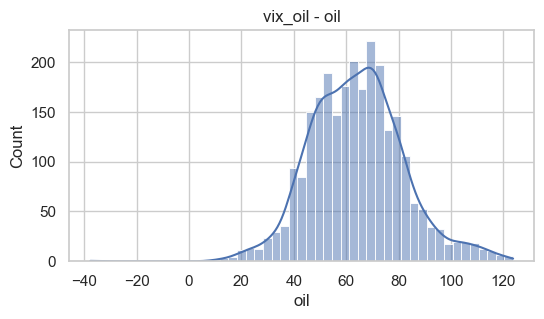

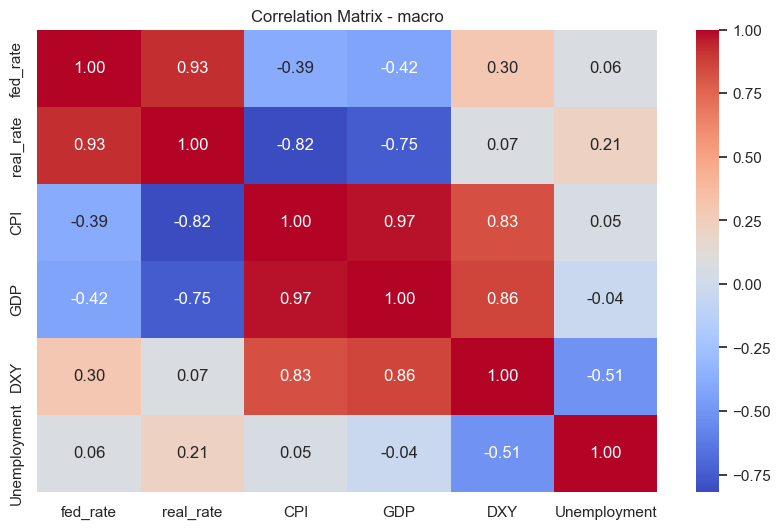

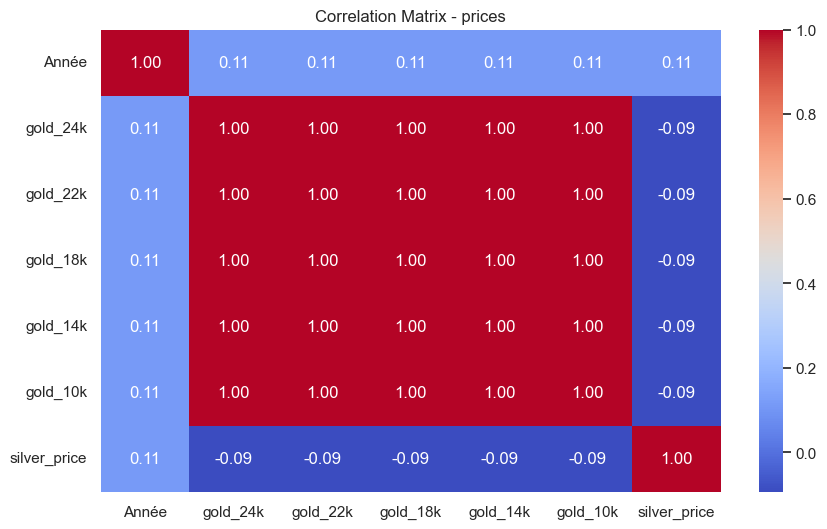

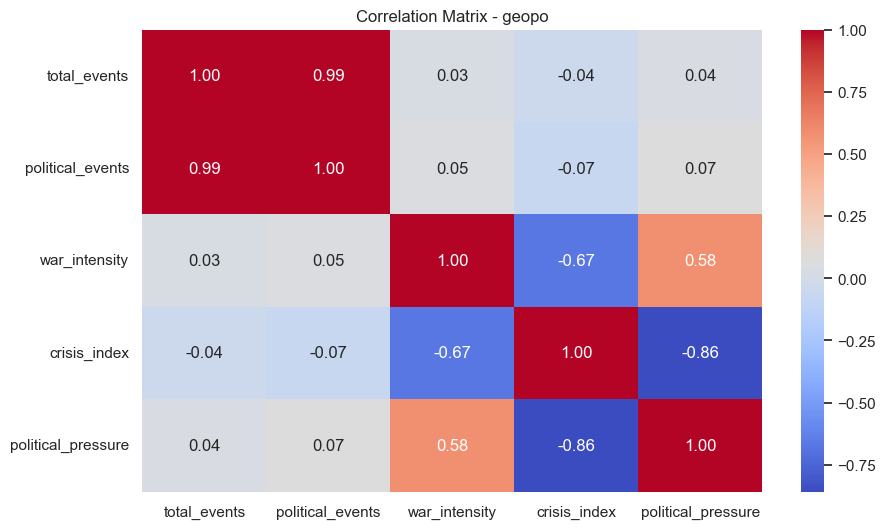

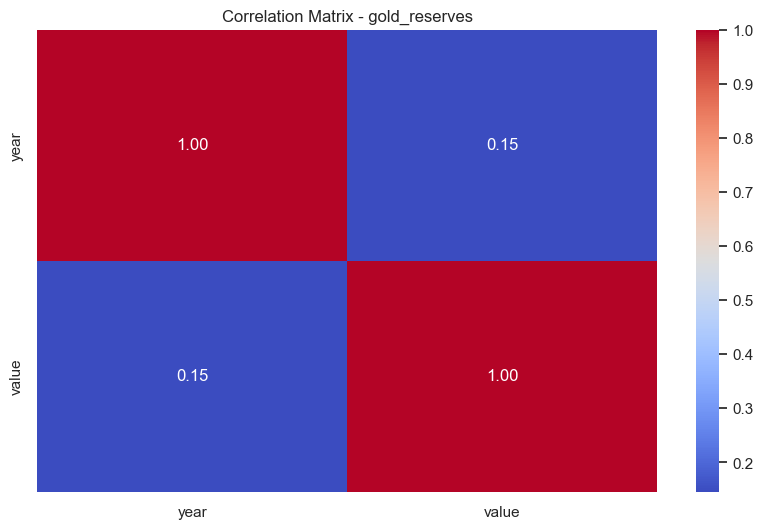

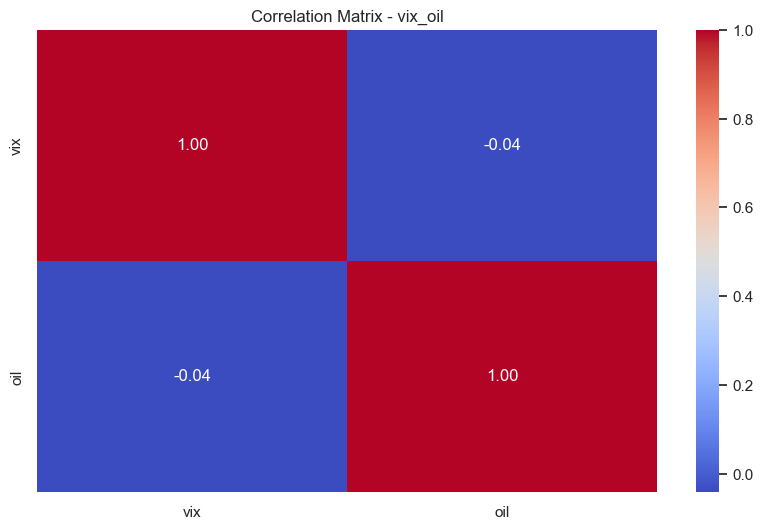

In [18]:
#valeurs numeriques distribution
def plot_distributions(df, name):
    num_cols = df.select_dtypes(include=np.number).columns
    
    for col in num_cols:
        plt.figure(figsize=(6,3))
        sns.histplot(df[col].dropna(), kde=True)
        plt.title(f"{name} - {col}")
        plt.show()

for name, df in dfs.items():
    if df is not None:
        plot_distributions(df, name)
def correlation_matrix(df, name):
    num_df = df.select_dtypes(include=np.number)
    
    if len(num_df.columns) > 1:
        plt.figure(figsize=(10,6))
        sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
        plt.title(f"Correlation Matrix - {name}")
        plt.show()

for name, df in dfs.items():
    if df is not None:
        correlation_matrix(df, name)


In [ ]:
#matrice de correlation
def correlation_matrix(df, name):
    num_df = df.select_dtypes(include=np.number)
    
    if len(num_df.columns) > 1:
        plt.figure(figsize=(10,6))
        sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
        plt.title(f"Correlation Matrix - {name}")
        plt.show()

for name, df in dfs.items():
    if df is not None:
        correlation_matrix(df, name)



In [ ]:
#Data Mining – détection d’outliers
def detect_outliers(df, name):
    num_cols = df.select_dtypes(include=np.number).columns
    
    for col in num_cols:
        plt.figure(figsize=(6,2))
        sns.boxplot(x=df[col])
        plt.title(f"{name} - Outliers: {col}")
        plt.show()

for name, df in dfs.items():
    if df is not None:
        detect_outliers(df, name)


In [ ]:
# Analyse temporelle
def time_series_plot(df, name, date_col="date"):
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.sort_values(date_col)
        
        num_cols = df.select_dtypes(include=np.number).columns
        
        for col in num_cols:
            plt.figure(figsize=(10,4))
            plt.plot(df[date_col], df[col])
            plt.title(f"{name} - {col} over time")
            plt.xticks(rotation=45)
            plt.show()

for name, df in dfs.items():
    if df is not None:
        time_series_plot(df, name)


In [ ]:
# Exemple merge (à adapter selon tes colonnes)
df_merged = prices_df.copy()

if "date" in macro_df.columns:
    df_merged = df_merged.merge(macro_df, on="date", how="left")

if "date" in geopo_df.columns:
    df_merged = df_merged.merge(geopo_df, on="date", how="left")

if "date" in vix_oil_df.columns:
    df_merged = df_merged.merge(vix_oil_df, on="date", how="left")

print(df_merged.shape)


In [ ]:
#correlation finale avec target gold silver
plt.figure(figsize=(12,6))
corr = df_merged.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")
plt.title("Global Correlation Matrix")
plt.show()

# Correlation avec gold
if "gold_price" in df_merged.columns:
    print("\n🎯 Corrélation avec GOLD:")
    print(corr["gold_price"].sort_values(ascending=False))


In [ ]:
#lag features:
# Lag features (impact retardé des événements)
for lag in [1, 7, 30]:
    df_merged[f"gold_lag_{lag}"] = df_merged["gold_price"].shift(lag)

# Rolling mean
df_merged["gold_ma_7"] = df_merged["gold_price"].rolling(7).mean()
df_merged["gold_ma_30"] = df_merged["gold_price"].rolling(30).mean()
